# Phase 1 — Analyse exploratoire (EDA)

**Dataset** : [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) — ULB / Worldline  
284 807 transactions · 492 fraudes (0,172 %) · features `V1`–`V28` (PCA anonymisées) · `Time` · `Amount` · `Class`

## Plan du notebook
1. Chargement & profiling général
2. Distribution de `Class` — déséquilibre
3. Analyse de `Time` — structure temporelle
4. Analyse de `Amount` — distribution & comparaison par classe
5. Features `V1`–`V28` — séparation des classes
6. Matrice de corrélation
7. Conclusions & décisions pour la suite

## 0. Imports

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Config projet
from src.config import RAW_DATA_PATH, RANDOM_SEED

# Reproductibilité
np.random.seed(RANDOM_SEED)

# Style graphiques
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
REPORTS_DIR = Path('../reports')
REPORTS_DIR.mkdir(exist_ok=True)

print('Librairies chargées OK')

Librairies chargées OK


## 1. Chargement & profiling général

In [2]:
df = pd.read_csv(RAW_DATA_PATH)
print(f'Shape : {df.shape[0]:,} lignes  x  {df.shape[1]} colonnes')
df.head(3)

Shape : 284,807 lignes  x  31 colonnes


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [3]:
# Types & valeurs manquantes
info = pd.DataFrame({
    'dtype'  : df.dtypes,
    'non_null': df.notna().sum(),
    'pct_null': (df.isna().mean() * 100).round(2)
})
print(info.to_string())

          dtype  non_null  pct_null
Time    float64    284807       0.0
V1      float64    284807       0.0
V2      float64    284807       0.0
V3      float64    284807       0.0
V4      float64    284807       0.0
V5      float64    284807       0.0
V6      float64    284807       0.0
V7      float64    284807       0.0
V8      float64    284807       0.0
V9      float64    284807       0.0
V10     float64    284807       0.0
V11     float64    284807       0.0
V12     float64    284807       0.0
V13     float64    284807       0.0
V14     float64    284807       0.0
V15     float64    284807       0.0
V16     float64    284807       0.0
V17     float64    284807       0.0
V18     float64    284807       0.0
V19     float64    284807       0.0
V20     float64    284807       0.0
V21     float64    284807       0.0
V22     float64    284807       0.0
V23     float64    284807       0.0
V24     float64    284807       0.0
V25     float64    284807       0.0
V26     float64    284807   

In [4]:
# Doublons exacts
n_dup = df.duplicated().sum()
print(f'Doublons exacts : {n_dup} ({n_dup/len(df)*100:.3f} %)')

# Stats descriptives sur Time et Amount
df[['Time', 'Amount']].describe().round(2)

Doublons exacts : 1081 (0.380 %)


,Time,Amount
count,284807.00,284807.00
mean,94813.86,88.35
std,47488.15,250.12
min,0.00,0.00
25%,54201.50,5.60
50%,84692.00,22.00
75%,139320.50,77.16
max,172792.00,25691.16


## 2. Distribution de `Class` — déséquilibre

> **Rappel** : l'accuracy est inutile ici (99,83 % en prédisant 'jamais de fraude').  
> Métrique principale retenue : **AUPRC** (Average Precision = aire sous la courbe Précision-Rappel).

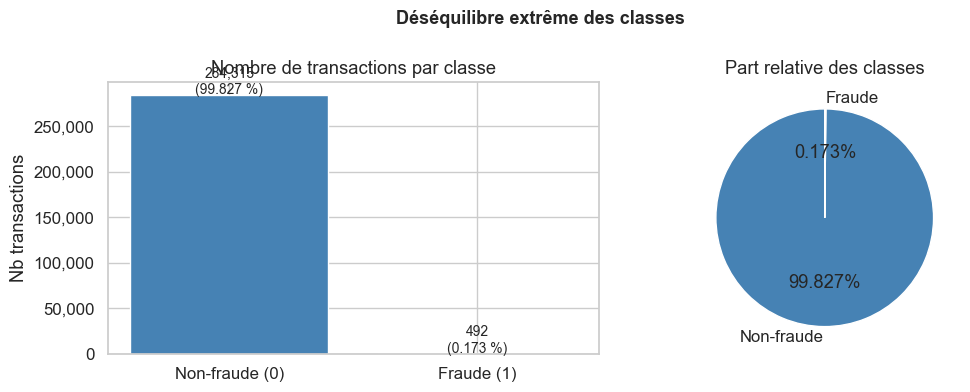

Ratio : 1 fraude pour 577 transactions légitimes


In [5]:
counts = df['Class'].value_counts()
pct    = df['Class'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Barplot
axes[0].bar(['Non-fraude (0)', 'Fraude (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='white')
for i, (v, p) in enumerate(zip(counts.values, pct.values)):
    axes[0].text(i, v + 1000, f'{v:,}\n({p:.3f} %)', ha='center', fontsize=10)
axes[0].set_title('Nombre de transactions par classe')
axes[0].set_ylabel('Nb transactions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Pie
axes[1].pie(counts.values, labels=['Non-fraude', 'Fraude'],
            autopct='%1.3f%%', colors=['steelblue', 'tomato'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Part relative des classes')

plt.suptitle('Déséquilibre extrême des classes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Ratio : 1 fraude pour {int(counts[0]/counts[1])} transactions légitimes')

## 3. Analyse de `Time` — structure temporelle

`Time` = secondes écoulées depuis la 1ʳᵉ transaction du dataset (~48 h de données).  
On reconstruit l'heure de la journée pour détecter des patterns diurnes/nocturnes.

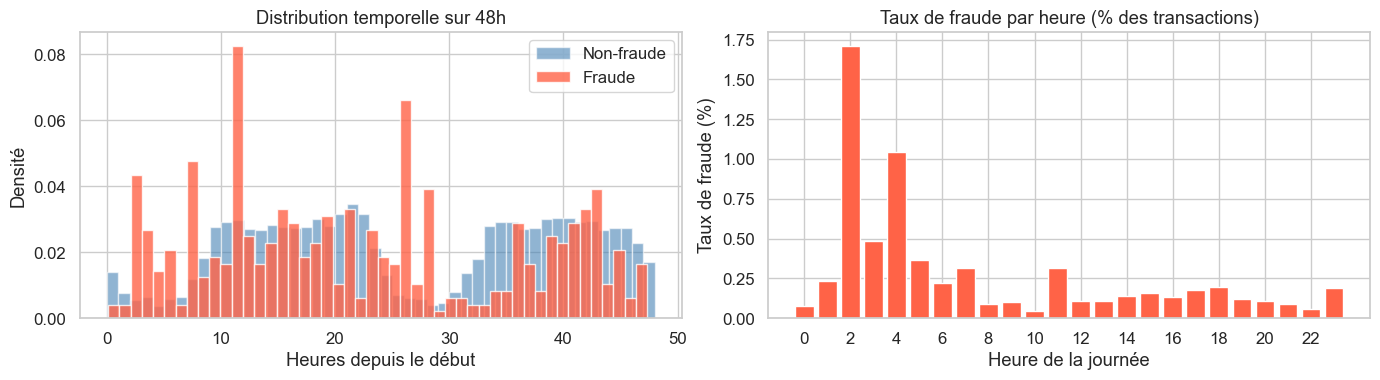

Heures avec le + de fraudes (volume absolu):
hour
2.0     57
11.0    53
18.0    33
17.0    29
15.0    26


In [6]:
# Reconstruction de l'heure
df['hour'] = (df['Time'] // 3600) % 24

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution de Time sur 48h
axes[0].hist(df.loc[df.Class==0, 'Time'] / 3600, bins=48,
             alpha=0.6, color='steelblue', label='Non-fraude', density=True)
axes[0].hist(df.loc[df.Class==1, 'Time'] / 3600, bins=48,
             alpha=0.8, color='tomato', label='Fraude', density=True)
axes[0].set_xlabel('Heures depuis le début')
axes[0].set_ylabel('Densité')
axes[0].set_title('Distribution temporelle sur 48h')
axes[0].legend()

# Taux de fraude par heure de la journée
fraud_rate = df.groupby('hour')['Class'].mean() * 100
fraud_count = df.groupby('hour')['Class'].sum()
axes[1].bar(fraud_rate.index, fraud_rate.values, color='tomato', edgecolor='white')
axes[1].set_xlabel('Heure de la journée')
axes[1].set_ylabel('Taux de fraude (%)')
axes[1].set_title('Taux de fraude par heure (% des transactions)')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig02_time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Heures avec le + de fraudes (volume absolu):')
print(fraud_count.sort_values(ascending=False).head(5).to_string())

## 4. Analyse de `Amount`

`Amount` = montant de la transaction — seule variable brute directement interprétable avec `Time`.  
Elle est très asymétrique et servira de base à la **structure de coût** (faux négatifs = montant perdu).

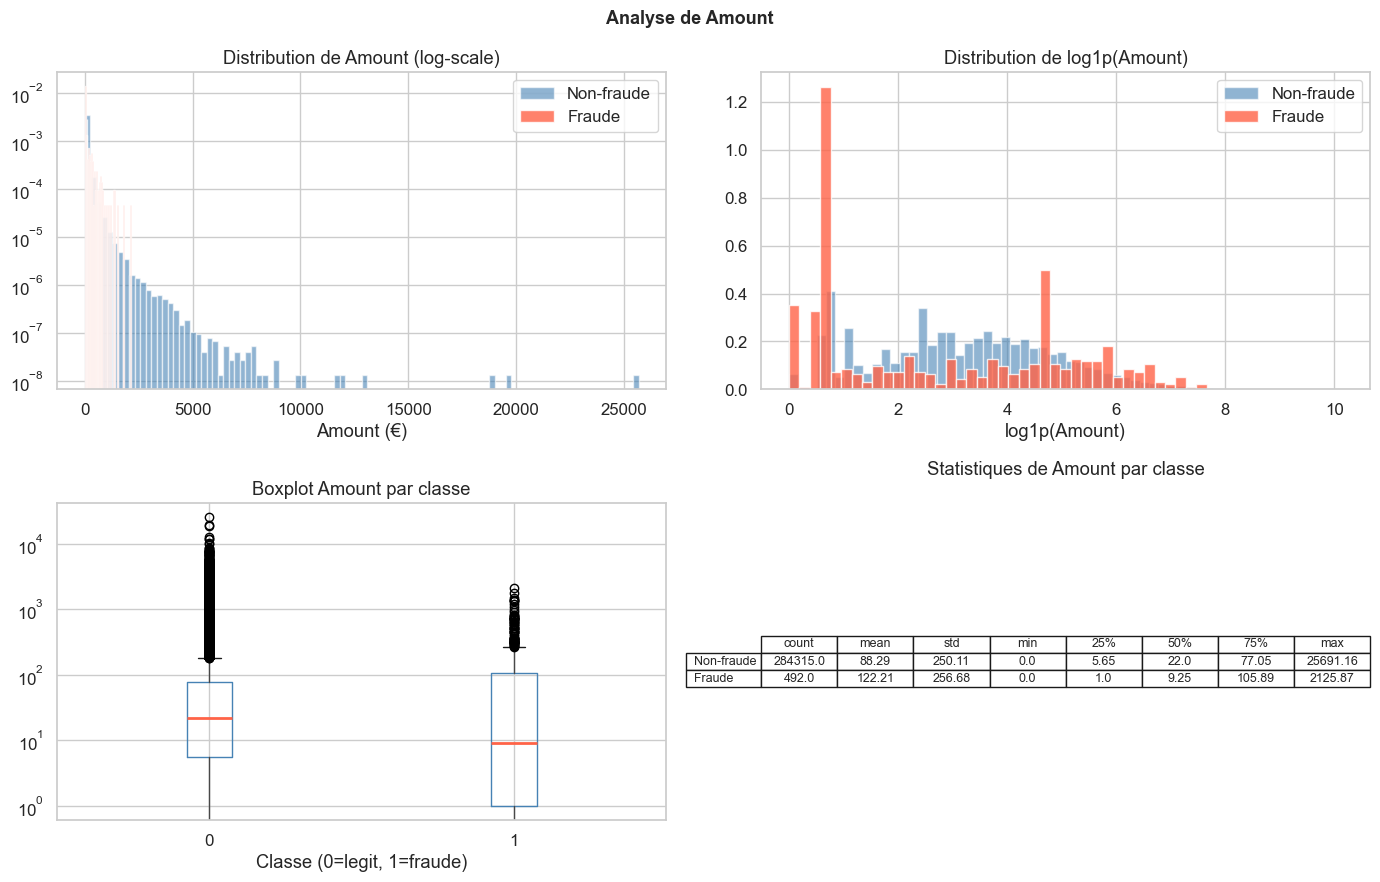

Montant total fraudé   : 60,127.97 €
Montant médian (fraude): 9.25 €
Montant médian (légit) : 22.00 €


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

legit  = df.loc[df.Class == 0, 'Amount']
fraud  = df.loc[df.Class == 1, 'Amount']

# 1. Distribution brute (log-scale)
axes[0,0].hist(legit,  bins=100, alpha=0.6, color='steelblue',
               label='Non-fraude', density=True, log=True)
axes[0,0].hist(fraud,  bins=50,  alpha=0.8, color='tomato',
               label='Fraude',    density=True, log=True)
axes[0,0].set_title('Distribution de Amount (log-scale)')
axes[0,0].set_xlabel('Amount (€)')
axes[0,0].legend()

# 2. Distribution log1p(Amount)
axes[0,1].hist(np.log1p(legit), bins=60, alpha=0.6, color='steelblue',
               label='Non-fraude', density=True)
axes[0,1].hist(np.log1p(fraud), bins=40, alpha=0.8, color='tomato',
               label='Fraude',    density=True)
axes[0,1].set_title('Distribution de log1p(Amount)')
axes[0,1].set_xlabel('log1p(Amount)')
axes[0,1].legend()

# 3. Boxplot Amount par classe
df.boxplot(column='Amount', by='Class', ax=axes[1,0],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='tomato', linewidth=2))
axes[1,0].set_title('Boxplot Amount par classe')
axes[1,0].set_xlabel('Classe (0=legit, 1=fraude)')
axes[1,0].set_yscale('log')
plt.sca(axes[1,0])
plt.title('Boxplot Amount par classe')

# 4. Stats comparées
stats = df.groupby('Class')['Amount'].describe().round(2)
axes[1,1].axis('off')
table = axes[1,1].table(
    cellText=stats.values,
    rowLabels=['Non-fraude', 'Fraude'],
    colLabels=stats.columns,
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
axes[1,1].set_title('Statistiques de Amount par classe', pad=20)

plt.suptitle('Analyse de Amount', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig03_amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Montant total fraudé
total_fraude = fraud.sum()
print(f'Montant total fraudé   : {total_fraude:,.2f} €')
print(f'Montant médian (fraude): {fraud.median():.2f} €')
print(f'Montant médian (légit) : {legit.median():.2f} €')

## 5. Features `V1`–`V28` — pouvoir discriminant

> Ces colonnes sont des **composantes PCA anonymisées** : on ne peut pas les interpréter  
> sémantiquement, mais on peut mesurer lesquelles séparent le mieux les deux classes.

On utilise un score simple : différence absolue des moyennes normalisée par l'écart-type poolé  
(équivalent d'un Cohen's d univarié).

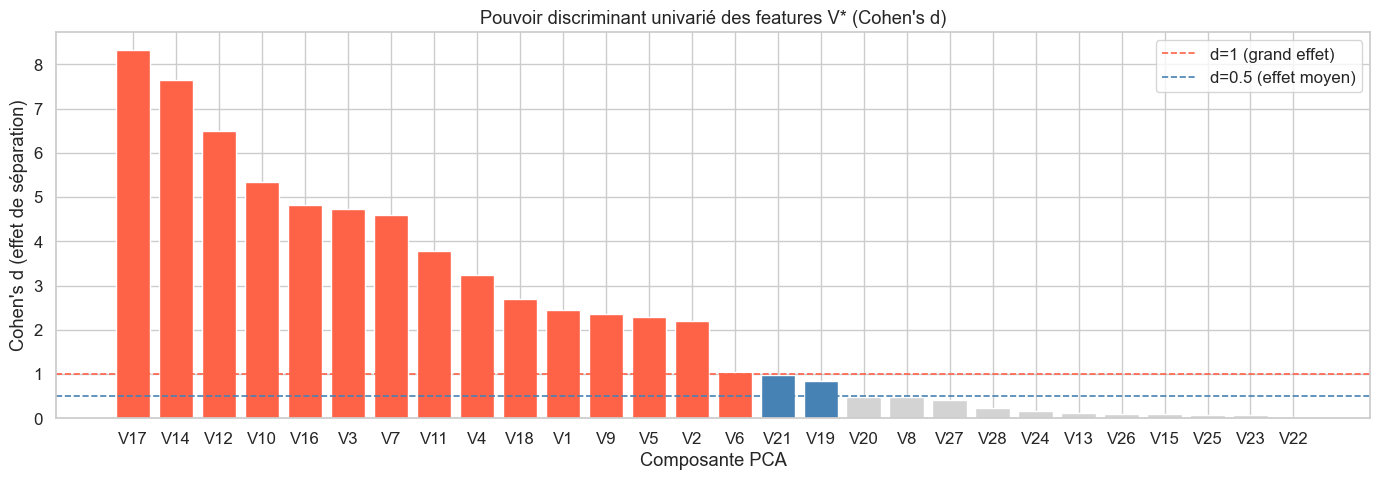

Top 5 features discriminantes :
V17    8.318
V14    7.644
V12    6.500
V10    5.350
V16    4.827
 
⚠️ Ces features sont des composantes PCA anonymisées : on sait qu'elles comptent, pas ce qu'elles signifient.


In [10]:
v_cols = [c for c in df.columns if c.startswith('V')]

# Cohen's d univarié pour chaque V_i
fraud_mask = df['Class'] == 1
cohens_d = {}
for col in v_cols:
    m0, s0 = df.loc[~fraud_mask, col].mean(), df.loc[~fraud_mask, col].std()
    m1, s1 = df.loc[fraud_mask,  col].mean(), df.loc[fraud_mask,  col].std()
    n0, n1 = (~fraud_mask).sum(), fraud_mask.sum()
    pooled_std = np.sqrt(((n0-1)*s0**2 + (n1-1)*s1**2) / (n0+n1-2))
    cohens_d[col] = abs(m1 - m0) / pooled_std if pooled_std > 0 else 0

d_series = pd.Series(cohens_d).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['tomato' if v >= 1.0 else 'steelblue' if v >= 0.5 else 'lightgray'
          for v in d_series.values]
ax.bar(d_series.index, d_series.values, color=colors, edgecolor='white')
ax.axhline(1.0, color='tomato',    linestyle='--', linewidth=1.2, label='d=1 (grand effet)')
ax.axhline(0.5, color='steelblue', linestyle='--', linewidth=1.2, label='d=0.5 (effet moyen)')
ax.set_xlabel('Composante PCA')
ax.set_ylabel("Cohen's d (effet de séparation)")
ax.set_title("Pouvoir discriminant univarié des features V* (Cohen's d)")
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig04_v_discrimination.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features discriminantes :')
print(d_series.head(5).round(3).to_string())
print(" \n⚠️ Ces features sont des composantes PCA anonymisées : on sait qu'elles comptent, pas ce qu'elles signifient.")

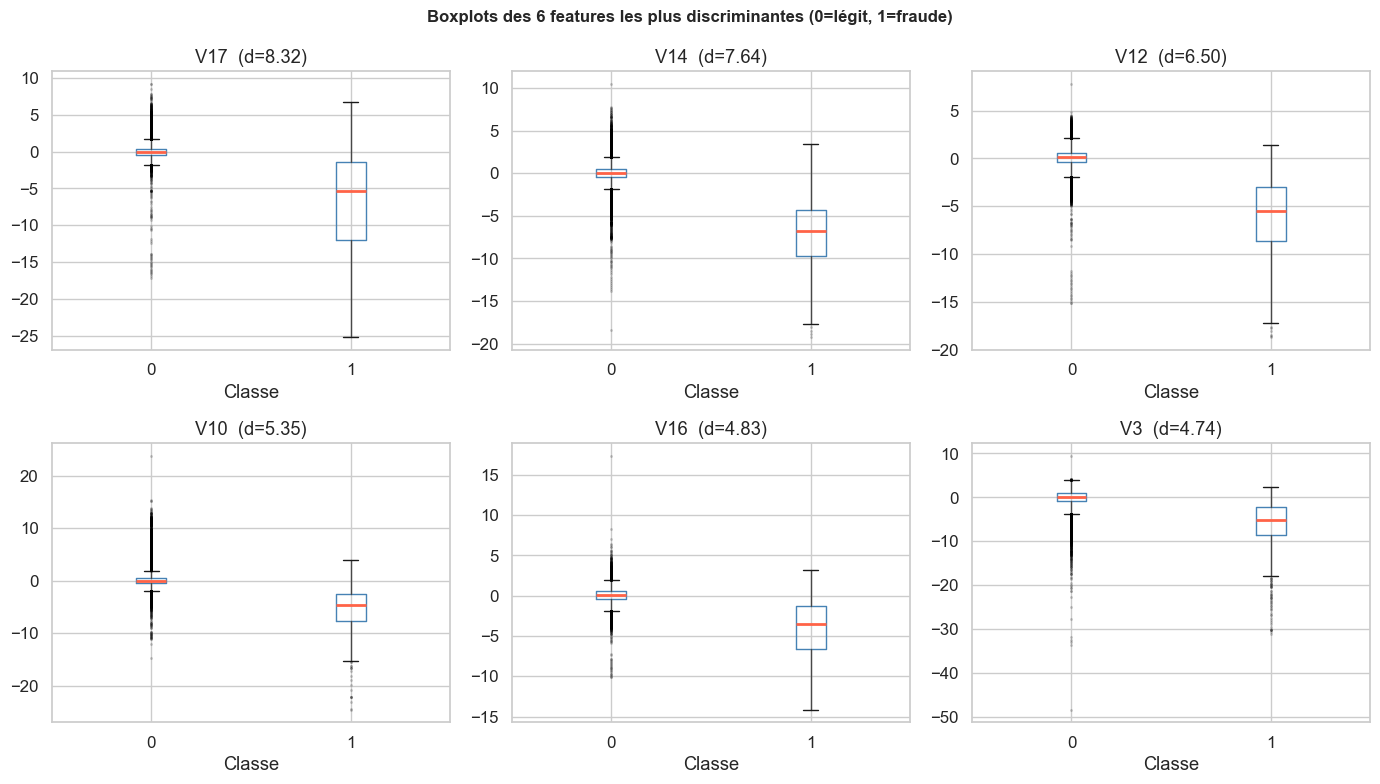

In [11]:
# Boxplots des 6 features les plus discriminantes
top6 = d_series.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), top6):
    df.boxplot(column=col, by='Class', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='tomato', linewidth=2),
               flierprops=dict(marker='.', alpha=0.2, markersize=2))
    ax.set_title(f'{col}  (d={cohens_d[col]:.2f})')
    ax.set_xlabel('Classe')
    plt.sca(ax)
    plt.title(f'{col}  (d={cohens_d[col]:.2f})')

plt.suptitle('Boxplots des 6 features les plus discriminantes (0=légit, 1=fraude)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig05_top_v_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Matrice de corrélation

> Les `V*` étant issues d'une PCA, elles sont par construction **décorrélées entre elles**.  
> La heatmap confirme cela — seules `Time`, `Amount` et `Class` peuvent montrer des corrélations avec les `V*`.

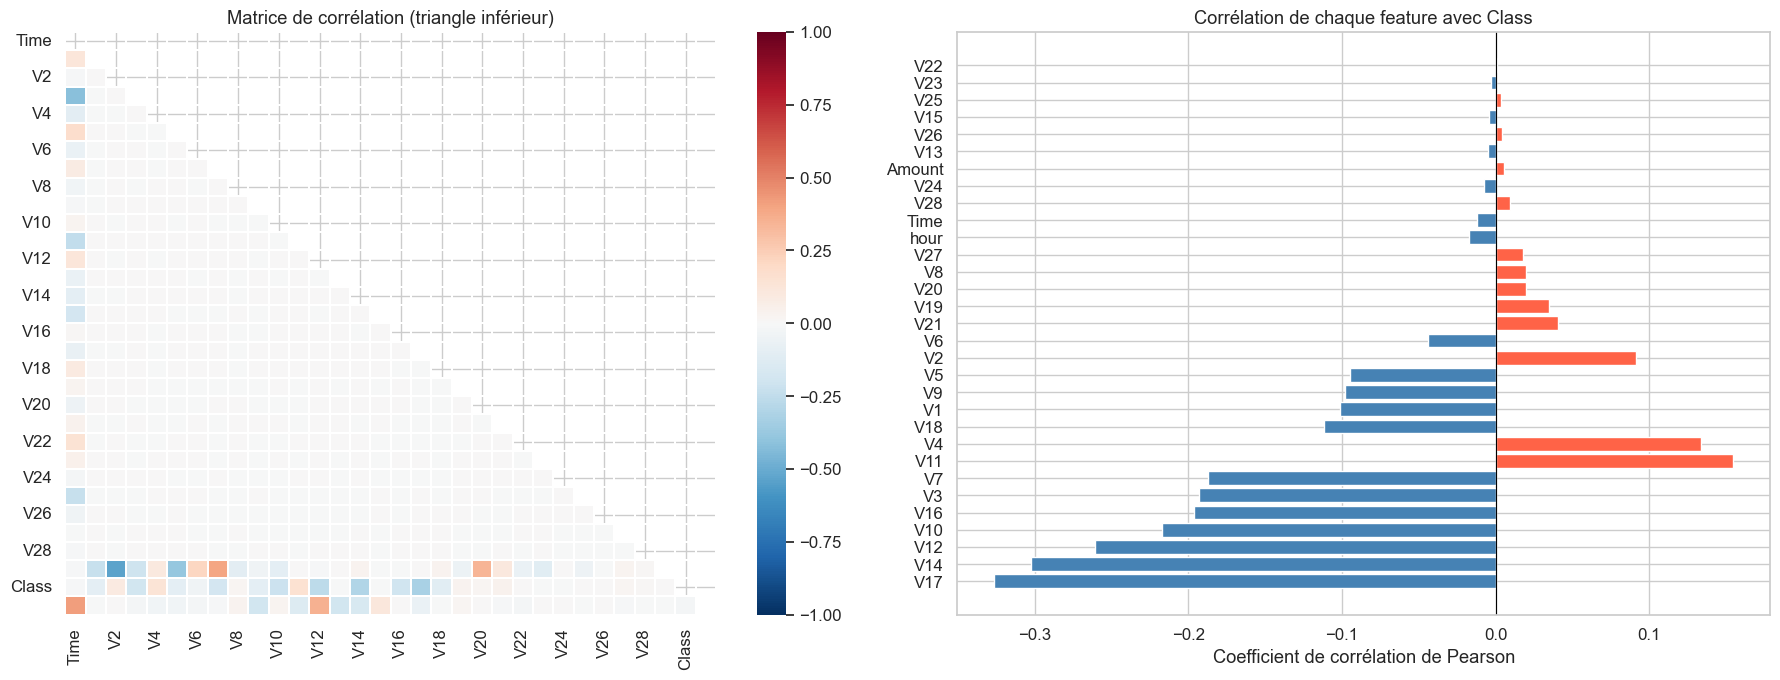

Top 5 features les + corrélées avec Class :
V17   -0.326
V14   -0.303
V12   -0.261
V10   -0.217
V16   -0.197


In [12]:
corr = df.corr()

# Corrélation de chaque feature avec Class (tri)
corr_class = corr['Class'].drop('Class').sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap complète
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[0],
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.1, linecolor='white',
            xticklabels=2, yticklabels=2)
axes[0].set_title('Matrice de corrélation (triangle inférieur)')

# Barplot corrélation avec Class
colors = ['tomato' if v > 0 else 'steelblue' for v in corr_class.values]
axes[1].barh(corr_class.index, corr_class.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Corrélation de chaque feature avec Class')
axes[1].set_xlabel('Coefficient de corrélation de Pearson')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig06_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features les + corrélées avec Class :')
print(corr_class.head(5).round(3).to_string())

## 7. Conclusions & décisions pour la suite

### Chiffres clés issus de l'exécution

| Indicateur | Valeur |
|---|---|
| Lignes × colonnes | **284 807 × 31** |
| Valeurs manquantes | **0** — dataset entièrement propre |
| Doublons exacts | **1 081 (0,380 %)** — décision requise avant le split |
| Ratio fraude / légit | **1 fraude pour 577 transactions** |
| Montant total fraudé | **60 127,97 €** |
| Montant médian fraude | **9,25 €** (< médiane légit : 22,00 €) |
| Montant max | **25 691,16 €** |
| Heure avec + de fraudes | **2h du matin (57 fraudes)**, puis 11h (53) |
| Top feature discriminante | **V17** (Cohen's d = 8,32), puis V14 (7,64), V12 (6,50) |
| Top corrélation avec Class | **V17** (r = −0,326), V14 (−0,303), V12 (−0,261) |

### Constats

| Observation | Conséquence |
|---|---|
| Déséquilibre extrême (1/577) | Accuracy inutile → **AUPRC** comme métrique principale |
| 0 valeur manquante | Aucun imputing nécessaire |
| 1 081 doublons exacts (0,38 %) | **Supprimer avant le split** pour éviter la fuite train→test |
| Fraudes médianes à 9,25 € (< légit) | Les fraudeurs testent avec de **petits montants** — `Amount` seul est peu discriminant |
| Pics de fraude à 2h et 11h | `hour` sera une feature utile en Phase 4 |
| V17, V14, V12 : Cohen's d > 6 | Séparation quasi-parfaite — ces 3 features domineront le modèle |
| `V*` décorrélées entre elles (PCA) | Peu de feature engineering possible dessus |
| 60 127 € fraudés au total | Référence pour les **métriques de coût** (Phase 2 / Phase 9) |

### Décisions

- ✅ **Métrique** : AUPRC + métriques de coût (€ fraudés capturés vs frictions à 5 €/FP)
- ✅ **Doublons** : supprimer les 1 081 doublons **avant** le split
- ✅ **Split** : temporel via `Time` (≈ 80/20 chronologique, seuil ≈ 138 234 s)
- ✅ **Transformations** : `log1p(Amount)`, `hour = (Time // 3600) % 24`
- ✅ **Features V*** : conservation sans transformation, V17/V14/V12 seront les drivers principaux
- ✅ **Imbalance** : class_weight + SMOTE comparés en Phase 5 — undersampling peu adapté (492 fraudes seulement)

### Graphiques produits (dans `reports/`)
- `fig01_class_distribution.png` — déséquilibre 1/577
- `fig02_time_analysis.png` — pics à 2h et 11h
- `fig03_amount_analysis.png` — médiane fraude < médiane légit
- `fig04_v_discrimination.png` — V17, V14, V12 dominants
- `fig05_top_v_boxplots.png` — boxplots top 6 features
- `fig06_correlation.png` — corrélations avec Class